In [2]:
!pip install lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]


In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos solicitados
import lightgbm as lgb
import xgboost as xgb
from sklearn.neural_network import MLPRegressor # Usaremos el de sklearn por practicidad, a menos que prefieras Keras/TensorFlow

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de la gráfica
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")


# Configuración opcional para ver todas las columnas en Pandas
pd.set_option('display.max_columns', None)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [9]:
# Reemplaza 'ruta_a_tus_datos.csv' con el nombre real de tu archivo
df = pd.read_csv('/Users/myrnamigueldelatorre/Documents/Modulo 4/Practica2/sample_trans.csv') 


In [10]:
df.head()


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


In [ ]:
# 2. Convertir la fecha al formato correcto (detectando el formato MM/DD/YYYY)
df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# 3. Limpieza rápida: si hay algún nulo en ID de cliente o fecha, lo quitamos
df = df.dropna(subset=['cliente_unico_id', 'fecha_de_transaccion'])

# 4. Ordenar cronológicamente por cliente y fecha de compra
df = df.sort_values(['cliente_unico_id', 'fecha_de_transaccion']).reset_index(drop=True)

print(f"Dataset cargado con éxito.")
print(f"Total de registros (filas): {df.shape[0]:,}")
print(f"Clientes únicos en la base: {df['cliente_unico_id'].nunique():,}")
print(f"Rango de historia: desde {df['fecha_de_transaccion'].min().date()} hasta {df['fecha_de_transaccion'].max().date()}")
print("-" * 50)
df.head()

Dataset REAL cargado con éxito.
Total de registros (filas): 4,101,885
Clientes únicos en la base: 770,941
Rango de historia: desde 2024-09-01 hasta 2025-08-11
--------------------------------------------------


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,2024-09-05,Palacio de Hierro,LUJO MODA,42458996,000005d043269af46202a43748865e64,20240905_1003_42_7052.0,24000.0,24000.00
1,2024-09-08,Palacio de Hierro,JUGUETERIA,42622387,000005d043269af46202a43748865e64,20240908_1003_154_5622.0,479.0,479.00
2,2024-09-08,Palacio de Hierro,BOUTIQUES,31469808,000005d043269af46202a43748865e64,20240908_1003_168_8420.0,999.0,999.00
3,2024-09-09,E Commerce,CABALLEROS,43669152,000005d043269af46202a43748865e64,Sites-palacio-MX-Site.5008830804,2632.0,2269.00
4,2025-05-30,E Commerce,DAMAS,44229344,000005f709693df2d048c8396c1e6162,Sites-palacio-MX-Site.5011095287,2076.0,1789.66


In [12]:
# 1. Definimos la ventana de predicción (90 días a futuro para el CLV)
dias_prediccion = 90

fecha_maxima = df['fecha_de_transaccion'].max()
fecha_corte = fecha_maxima - pd.Timedelta(days=dias_prediccion)

print(f"Fecha máxima en tus datos: {fecha_maxima.date()}")
print(f"Fecha de corte (Tu 'Hoy' simulado): {fecha_corte.date()}")
print("=" * 50)

# 2. Separar la historia del futuro
# Pasado (Para entrenar al modelo con sus hábitos)
df_observacion = df[df['fecha_de_transaccion'] <= fecha_corte].copy()

# Futuro (Lo que el modelo intentará adivinar)
df_prediccion = df[df['fecha_de_transaccion'] > fecha_corte].copy()

# 3. Crear nuestra variable objetivo (Y)
target = df_prediccion.groupby('cliente_unico_id')['monto_neto'].sum().reset_index()
target.rename(columns={'monto_neto': 'target_clv'}, inplace=True)

print(f"Transacciones históricas (X): {df_observacion.shape[0]:,}")
print(f"Transacciones futuras (y): {df_prediccion.shape[0]:,}")
print(f"Clientes que volvieron a comprar en el futuro: {target.shape[0]:,}")
print("-" * 50)
target.head()

Fecha máxima en tus datos: 2025-08-11
Fecha de corte (Tu 'Hoy' simulado): 2025-05-13
Transacciones históricas (X): 3,283,959
Transacciones futuras (y): 817,926
Clientes que volvieron a comprar en el futuro: 312,707
--------------------------------------------------


,cliente_unico_id,target_clv
0,000005f709693df2d048c8396c1e6162,4509.84
1,00009b78cda0aff32a2bf0dab56b5f76,2950.00
2,00015b468fcfa6fa3aeaeb15a7663e61,5509.00
3,00018b559f3e018dd37fbe181c9ef115,1199.00
4,00018cd2f856ddfc65cc97d9aaca1fef,488.00


In [13]:
print("Iniciando la ingeniería de variables sobre los datos del pasado...")

# 1. COMPORTAMIENTO BÁSICO (RFM)
# Calculamos la fecha "actual" simulada para medir qué tan rápido regresan (Recency)
fecha_referencia = df_observacion['fecha_de_transaccion'].max()

rfm = df_observacion.groupby('cliente_unico_id').agg(
    recency=('fecha_de_transaccion', lambda x: (fecha_referencia - x.max()).days),
    frequency=('orden_de_venta', 'nunique'), # Cuántas órdenes distintas hizo
    monto_neto_total=('monto_neto', 'sum'),
    monto_neto_promedio=('monto_neto', 'mean'),
    monto_bruto_total=('monto_bruto', 'sum'),
    sku_unicos=('sku_producto', 'nunique')    # Cuántos productos distintos conoce
).reset_index()


# 2. PIVOTEAR LOS CANALES DE COMPRA (Hint 2)
# Queremos saber cuánto gasta el cliente en cada canal (Web, Palacio de Hierro, App, etc.)
pivot_canales = df_observacion.pivot_table(
    index='cliente_unico_id',
    columns='canal_de_compra',
    values='monto_neto',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Renombramos las columnas para saber que son de canales
pivot_canales.columns = ['cliente_unico_id'] + [f'monto_canal_{col}' for col in pivot_canales.columns[1:]]


# 3. PIVOTEAR LAS DIVISIONES (Hint 2)
# Queremos saber cuánto gasta en JUGUETERIA, DAMAS, GOURMET, etc.
pivot_divisiones = df_observacion.pivot_table(
    index='cliente_unico_id',
    columns='division',
    values='monto_neto',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Renombramos las columnas para saber que son de divisiones
pivot_divisiones.columns = ['cliente_unico_id'] + [f'monto_division_{col}' for col in pivot_divisiones.columns[1:]]


# 4. UNIR TODO EN NUESTRA MATRIZ DE CARACTERÍSTICAS (X)
# Juntamos el RFM con los pivotes usando el ID del cliente
X_features = rfm.merge(pivot_canales, on='cliente_unico_id', how='left')
X_features = X_features.merge(pivot_divisiones, on='cliente_unico_id', how='left')

print(f"¡Variables creadas! Ahora tenemos una tabla de {X_features.shape[0]} clientes únicos y {X_features.shape[1]} variables para analizar.")
X_features.head()

Iniciando la ingeniería de variables sobre los datos del pasado...
¡Variables creadas! Ahora tenemos una tabla de 682498 clientes únicos y 38 variables para analizar.


,cliente_unico_id,recency,frequency,monto_neto_total,monto_neto_promedio,monto_bruto_total,sku_unicos,monto_canal_Boutiques,monto_canal_Casa Palacio,monto_canal_E Commerce,monto_canal_La BPH,monto_canal_Outlets,monto_canal_Palacio de Hierro,monto_division_BELLEZA,monto_division_BOUTIQUES,monto_division_CABALLEROS,monto_division_CONCESIONARIOS,monto_division_DAMAS,monto_division_DEPORTES,monto_division_GOURMET,monto_division_HOGAR,monto_division_INFANTILES,monto_division_JUGUETERIA,monto_division_LUJO MODA,monto_division_MARCAS PROPIAS,monto_division_NUEVOS NEGOCIOS,monto_division_OUTLET,monto_division_PREPAGOS Y DEPOSITOS NO OBJETO DE IVA,monto_division_PROMOCIONES ESPECIALES,monto_division_RELOJERIA JOYERIA Y ESCRITURA,monto_division_SERVICIOS AL CLIENTE HARDLINES,monto_division_SERVICIOS AL CLIENTE PH,monto_division_SERVICIOS RESTAURANTES,monto_division_SERVICIOS SPA,monto_division_SERVICIOS VARIOS,monto_division_TECNOLOGIA,monto_division_TECNOLOGÍA,monto_division_TERCEROS NO OBJETO DE IVA
0,000005d043269af46202a43748865e64,246,4,27747.00,6936.75,28110.0,4,0.0,0.0,2269.00,0.0,0.0,25478.0,0.00,999.0,2269.0,0.0,0.0,0.0,0.0,0.0,0.00,479.0,24000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,000008fe7c2d1f99f5dae8afb4235c8c,85,1,1438.00,719.00,1438.0,2,0.0,0.0,0.00,0.0,0.0,1438.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1438.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0000444fcca40a6242c5279210021108,120,1,585.86,585.86,679.6,1,0.0,0.0,585.86,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,585.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00004cfade0c9f7a491c7472051a5673,86,1,2327.59,2327.59,2700.0,1,0.0,0.0,2327.59,0.0,0.0,0.0,2327.59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00007330e325bb763ecdb0690667d6b9,249,1,2319.00,2319.00,2690.0,1,0.0,0.0,2319.00,0.0,0.0,0.0,0.00,2319.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Unimos las características del pasado con la variable objetivo del futuro
dataset_final = X_features.merge(target, on='cliente_unico_id', how='left')

# Si el cliente no tiene registro en el futuro, significa que gastó 0 pesos
dataset_final['target_clv'] = dataset_final['target_clv'].fillna(0)

print(f"Dataset listo para modelar.")
print(f"Total de clientes para entrenamiento: {dataset_final.shape[0]:,}")
print(f"Promedio de gasto futuro (CLV) de los clientes: ${dataset_final['target_clv'].mean():.2f}")
print(f"Máximo gasto futuro detectado: ${dataset_final['target_clv'].max():.2f}")
print("-" * 50)

# Separamos definitivamente las variables predictoras (X) de la variable objetivo (y)
# Quitamos el ID del cliente porque los modelos de ML solo entienden números, no textos largos
X = dataset_final.drop(columns=['cliente_unico_id', 'target_clv'])
y = dataset_final['target_clv']

print("Variables predictoras finales (X):", list(X.columns))

Dataset listo para modelar.
Total de clientes para entrenamiento: 682,498
Promedio de gasto futuro (CLV) de los clientes: $2341.53
Máximo gasto futuro detectado: $22139517.05
--------------------------------------------------
Variables predictoras finales (X): ['recency', 'frequency', 'monto_neto_total', 'monto_neto_promedio', 'monto_bruto_total', 'sku_unicos', 'monto_canal_Boutiques', 'monto_canal_Casa Palacio', 'monto_canal_E Commerce', 'monto_canal_La BPH', 'monto_canal_Outlets', 'monto_canal_Palacio de Hierro', 'monto_division_BELLEZA', 'monto_division_BOUTIQUES', 'monto_division_CABALLEROS', 'monto_division_CONCESIONARIOS', 'monto_division_DAMAS', 'monto_division_DEPORTES', 'monto_division_GOURMET', 'monto_division_HOGAR', 'monto_division_INFANTILES', 'monto_division_JUGUETERIA', 'monto_division_LUJO MODA', 'monto_division_MARCAS PROPIAS', 'monto_division_NUEVOS NEGOCIOS', 'monto_division_OUTLET', 'monto_division_PREPAGOS Y DEPOSITOS NO OBJETO DE IVA', 'monto_division_PROMOCIONES 

In [15]:
# 1. Separar en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Crear el escalador
scaler = StandardScaler()

# 3. Ajustar el escalador SOLO con los datos de entrenamiento y transformar ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos listos para los algoritmos:")
print(f"Tamaño de X_train (para aprender): {X_train.shape}")
print(f"Tamaño de X_test (para validar): {X_test.shape}")

Datos listos para los algoritmos:
Tamaño de X_train (para aprender): (545998, 37)
Tamaño de X_test (para validar): (136500, 37)


In [ ]:
# Rellenamos cualquier valor nulo en X_train y X_test con 0 
# Esto asegura que la Red Neuronal reciba puros números limpios
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Volvemos a aplicar el escalador sobre los datos ya limpios de nulos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Datos limpios de NaNs y re-escalados!")

¡Datos perfectamente limpios de NaNs y re-escalados!


In [18]:
# 1. DEFINIR LOS MODELOS
# LightGBM y XGBoost trabajan excelente con los datos originales (sin escalar)
modelo_lgb = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
modelo_xgb = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.05)

# Las Redes Neuronales (MLP) OBLIGATORIAMENTE necesitan los datos escalados
modelo_nn = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)

# 2. ENTRENAR LOS MODELOS
print("Entrenando LightGBM...")
modelo_lgb.fit(X_train, y_train)

print("Entrenando XGBoost...")
modelo_xgb.fit(X_train, y_train)

print("Entrenando Red Neuronal (MLP)...")
modelo_nn.fit(X_train_scaled, y_train)

print("¡Modelos entrenados con éxito!\n")

# 3. GENERAR PREDICCIONES
preds_lgb = modelo_lgb.predict(X_test)
preds_xgb = modelo_xgb.predict(X_test)
preds_nn = modelo_nn.predict(X_test_scaled)

# 4. EVALUAR Y COMPARAR MÉTRICAS
resultados = []

for nombre, y_pred in zip(['LightGBM', 'XGBoost', 'Red Neuronal'], [preds_lgb, preds_xgb, preds_nn]):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    resultados.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# Convertir a DataFrame para que se vea como una tabla limpia
df_metricas = pd.DataFrame(resultados)
print("=== TABLA DE COMPARACIÓN FINALES ===")
df_metricas

Entrenando LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8283
[LightGBM] [Info] Number of data points in the train set: 545998, number of used features: 36
[LightGBM] [Info] Start training from score 2343.214115
Entrenando XGBoost...
Entrenando Red Neuronal (MLP)...
¡Modelos entrenados con éxito!

=== TABLA DE COMPARACIÓN FINALES ===


,Modelo,MAE,RMSE,R2
0,LightGBM,3039.725424,17490.973818,0.292949
1,XGBoost,3023.640447,17227.593323,0.314082
2,Red Neuronal,3042.643589,14737.237489,0.498056


/var/folders/m1/5yq9q7q116j21q9_14rkjkrw0000gn/T/ipykernel_28327/119382148.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelo', y='R2', data=df_metricas, palette='viridis')


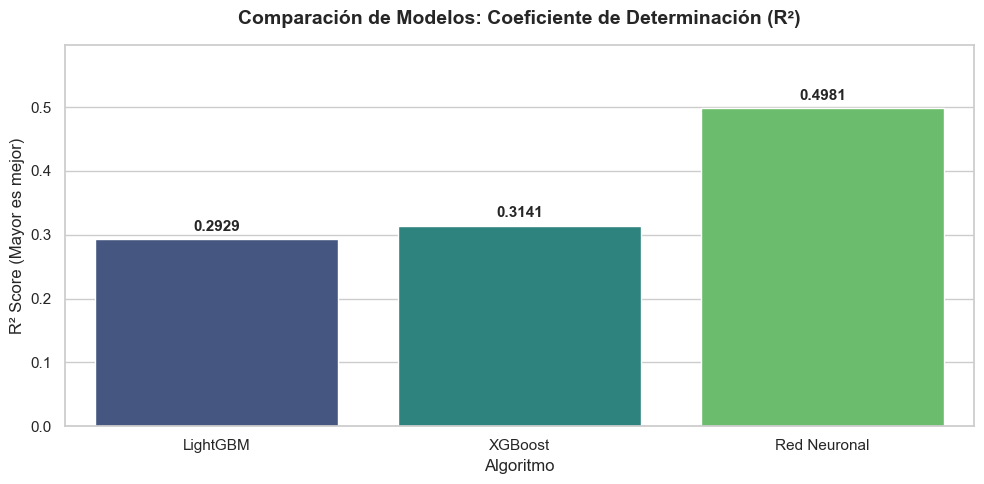

In [ ]:

# Graficamos el R2 (Coeficiente de Determinación) de cada modelo
# Recuerda que entre más cercano a 1 o 100%, mejor es el modelo
ax = sns.barplot(x='Modelo', y='R2', data=df_metricas, palette='viridis')

# Añadimos los valores numéricos arriba de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title('Comparación de Modelos: Coeficiente de Determinación (R²)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('R² Score (Mayor es mejor)', fontsize=12)
plt.xlabel('Algoritmo', fontsize=12)
plt.ylim(0, df_metricas['R2'].max() * 1.2) # Ajustamos el límite para que luzca bien

plt.tight_layout()
plt.show()